# **PhotoRing Effect Interactive**
#### By Jorge I. Zuluaga, Jaime Alvarado-Montes, Sebastian Numpaque and David Kipping

### **Useful Packages**

In [1]:
import numpy as np
import pandas as pd

from copy import deepcopy

import matplotlib.pyplot as plt

### **Loading GeoTrans**

In [2]:
geotrans_path = '/home/numpaque/kepler_51/Zuluaga_PhotoRing/GeoTrans'

import sys
sys.path.append(geotrans_path)

import geotrans2 as geo2

### **System Parameters**

In [3]:
System_Parameters = dict(\
#########################################
#SYSTEM PRIMARY PARAMETERS
#########################################
#//////////////////////////////
#DETECTOR
#//////////////////////////////
Ddet = 0.5,#Aperture, m
qeff = 1.0,#Quantum efficiency
#//////////////////////////////
#STAR
#//////////////////////////////
Mstar = 1.0*geo2.MSUN,
Rstar = 1.0*geo2.RSUN,
Lstar = 1.0*geo2.LSUN,
Tstar = 1.0*geo2.TSUN,
Dstar = 1*geo2.KILO*geo2.PARSEC,
c1 = 0.70,#Limb Darkening
c2 = -0.24,#Limb Darkening
#//////////////////////////////
#ORBIT
#//////////////////////////////
ap = 1.0*geo2.AU,
ep = 0.0,
iorb = 90.0*geo2.DEG,
wp = 0.0*geo2.DEG,
#//////////////////////////////
#PLANET
#//////////////////////////////
Mplanet = 1.0*geo2.MSAT,
Rplanet = 1.0*geo2.RSAT,
fp = 0.0, #Oblateness
#//////////////////////////////
#RINGS
#//////////////////////////////
fe = geo2.RSAT_ARING/geo2.RSAT, #Exterior ring (Rp)
fi = geo2.RSAT_BRING/geo2.RSAT, #Interior ring (Rp)
ir = 45.0*geo2.DEG, #Ring inclination
phir = 45.0*geo2.DEG, #Ring roll angle
tau = 1.0, #Opacity
)

### **Creating a System**

In [4]:
System = geo2.RingedSystem(system = System_Parameters)
System

Star primary:
	 Ms = 1.988550e+30 kg
	 Rs = 6.963420e+08 kg
Planet primary:
	 Mp = 5.684600e+26 kg = 0.299505 MJUP = 2.858666e-04 Mstar
	 Rp = 5.823200e+07 km = 0.832945 RJUP = 8.362557e-02 Rstar
Rings primary:
	 fi,fe = 1.579887e+00,2.348794e+00 Rp
	 Inclination (orbit) = 45.0 deg
	 Roll (orbit) = 45.0 deg
	 Opacity = 1.00
Orbit primary:
	 ap = 1.495979e+11 km = 1.000000e+00 AU = 2.148339e+02 Rstar
	 Eccentricity = 0.00
	 Inclination (visual) = 90.00 deg
	 Periapsis argument = 0.00 deg

Planetary derivative:
	 Radius (relative) = 8.362557e-02 Rstar
Rings derivative:
	 Internal ring (relative) = 0.13 Rstar
	 External ring (relative) = 0.20 Rstar
	 Apparent inclination = 60.00 deg
	 Apparent roll = 35.26 deg
Orbit derivative:
	 Period = 3.155257e+07 s = 8.764604e+03 h = 3.651918e+02 d = 1.000526e+00 yr
	 Mean Angular velocity = 1.991338e-07 rad/s = 4.278070e-05 Rstar/s = 5.115744e-04 Rp/s
	 Central true anomaly = 2.700000e+02 deg
	 Central eccentric anomaly = -9.000000e+01 deg
	 Central

In [5]:
#########################################
# NO RINGEDPLANET
#########################################
NR_System = deepcopy(System)

NR_System.fe=1
NR_System.fi=1
NR_System.tau=0

NR_System.updateSystem()

### **Visualizing Planet**

In [6]:
def plot_planet(System, frac = 0.3, axis = None):

    if axis is None:
        fig = plt.figure(figsize = (3,3))
        ax = fig.add_subplot(111)
    else:
        ax = axis
        fig = axis.figure
        
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_axis_off()

    # Adjust parameters
    System.calculate_PR()
    System.updateSystem()

    # Plot planet
    fh = frac/(System.fe*System.Rp)
    fv = fh

    C = np.array([0.5, 0.5])
    Planet = geo2.Figure(C, fh*System.Rp, fv*System.Rp, 1.0, 0.0, 'Planet')
    Ringe = geo2.Figure(C, fh*System.Re, fv*System.Re*np.cos(System.ieff), np.cos(System.teff), np.sin(System.teff), 'Ringext')
    Ringi = geo2.Figure(C, fh*System.Ri, fv*System.Ri*np.cos(System.ieff), np.cos(System.teff), np.sin(System.teff), 'Ringint')
    geo2.plotEllipse(ax, Planet, patch = True, zorder = 10, color = 'k', transform = ax.transAxes)
    geo2.plotEllipse(ax, Ringe, zorder = 10, color = 'b', alpha = 0.2, transform = ax.transAxes)
    geo2.plotEllipse(ax, Ringi, zorder = 10, color = 'r', alpha = 0, transform = ax.transAxes)

    # return fig, ax

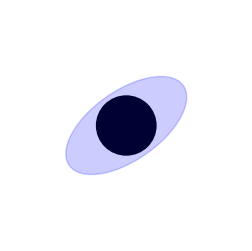

In [7]:
plot_planet(System)

### **Analytical Lightcurve**

In [8]:
def plot_lightcurve(System, axis = None):

    import warnings
    warnings.filterwarnings("ignore")

    #########################################
    #CONTACT TIMES
    #########################################
    tcsr = geo2.contactTimes(System)
    tcen, t1, t2, t3, t4 = tcsr
    tmin = t1 - 2*System.dtplanet
    tmax = t4 + 2*System.dtplanet
    Area = geo2.ringedPlanetArea(System)
    Area_NR = geo2.ringedPlanetArea(NR_System)

    #########################################
    #THEORETICAL
    #########################################
    Nts = 100
    ts = np.linspace(tmin, tmax, Nts)
    phase = np.zeros(Nts)
    fluxs = np.zeros(Nts)
    fluxs_NR = np.zeros(Nts)
    dt = System.dtplanet/2

    for i, t in enumerate(ts):
        flux = geo2.fluxLimbTime(t, Area, System)
        flux_NR = geo2.fluxLimbTime(t, Area_NR, NR_System)
        phase[i] = (t-System.tcen)/geo2.HOUR
        fluxs[i] = flux
        fluxs_NR[i] = flux_NR

    #########################################
    #PLOT
    #########################################
    if axis is None:
        fig, ax = plt.subplots(figsize = (8,8), dpi = 100)
    else:
        ax = axis
        fig = axis.figure

    #DATA POINTS
    ax.plot(phase,fluxs,'r-')
    ax.plot(phase,fluxs_NR,'k-', alpha = 0.7)

    #FLUX RANGE
    ymin = min(fluxs)
    ymax = max(fluxs)
    fy = 1+0.05*(ymax-ymin)/ymax

    #CONTACT TIMES
    color = 'b'
    targs = dict(verticalalignment = 'bottom',fontsize = 8,
            horizontalalignment = 'center',
            bbox = dict(fc = 'none',ec = 'none'))

    ax.axvline((t1-tcen)/geo2.HOUR,color = color, linewidth = 2, linestyle = ':')
    ax.text((t1-tcen)/geo2.HOUR,fy*ymax,'$t_1 = %.2f$'%((t1-tcen)/geo2.HOUR),**targs)

    ax.axvline((t2-tcen)/geo2.HOUR,color = color, linewidth = 2, linestyle = ':')
    ax.text((t2-tcen)/geo2.HOUR,fy*ymax,'$t_2 = %.2f$'%((t2-tcen)/geo2.HOUR),**targs)

    ax.axvline((t3-tcen)/geo2.HOUR,color = color, linewidth = 2, linestyle = ':')
    ax.text((t3-tcen)/geo2.HOUR,fy*ymax,'$t_3 = %.2f$'%((t3-tcen)/geo2.HOUR),**targs)

    ax.axvline((t4-tcen)/geo2.HOUR,color = color, linewidth = 2, linestyle = ':')
    ax.text((t4-tcen)/geo2.HOUR,fy*ymax,'$t_4 = %.2f$'%((t4-tcen)/geo2.HOUR),**targs)

    #DECORATION
    ax.set_ylim((ymin/fy,fy*ymax))
    ax.set_xlim(((tmin-tcen)/geo2.HOUR,(tmax-tcen)/geo2.HOUR))
    ax.set_xlabel(r"$t-t_{cen}$ [h]",fontsize = 14)
    ax.set_ylabel(r"Relative Flux",fontsize = 14)
    ax.grid()

    #fig.savefig("figures/lightcurve.png")

    # return fig, ax


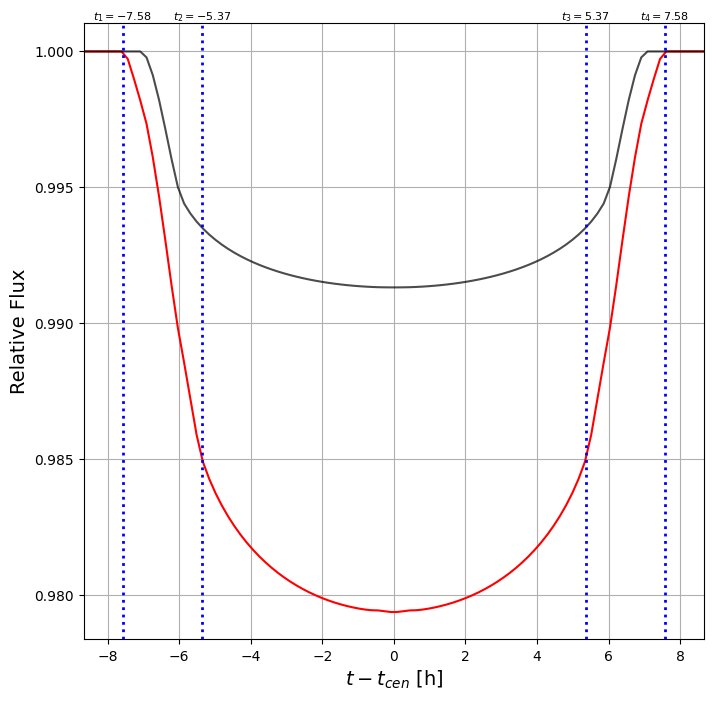

In [9]:
plot_lightcurve(System)

### **PhotoRing Effect**

In [10]:
def plot_PhotoRing(System, axis = None):

    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable

    if axis is None:
        fig, ax_cb = plt.subplots(figsize = (8,2))
    else:
        ax_cb = axis
        fig = axis.figure

    # PHOTORING RANGE
    vmin, vmax = -1, 1

    # COLORSCALE
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap('rainbow') 
    sm = ScalarMappable(norm=norm, cmap=cmap)
    cb = fig.colorbar(sm, cax = ax_cb, orientation = 'horizontal')
    cb.set_label(r'$\log_{10}\left(\rho_{\mathrm{obs}}/\rho_{\star}\right)$')

    # PHOTORING VALUE
    PR = System.calculate_PR()

    ax_cb.axvline(PR, color='k', linestyle='-', linewidth=1)
    ax_cb.axvline(0, color='k', linestyle=':', linewidth=1)
    ax_cb.text(PR, 1.05, '', color='k', ha='center', va='bottom', fontsize=12, transform=ax_cb.get_xaxis_transform())

    # return fig, ax_cb

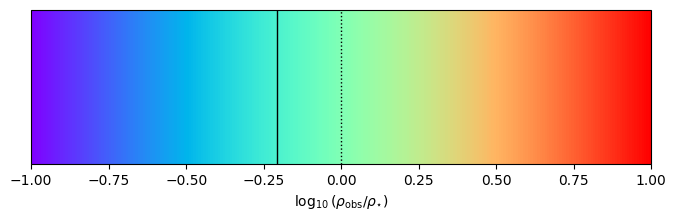

In [11]:
plot_PhotoRing(System)

## **Interactive Tool**

In [12]:
from ipywidgets import interact, FloatSlider

In [13]:

def interactive_photorings(ir = 45.0, phir =45.0):

    # UPDATE SYSTEM PARAMETERS
    System.ir = ir*geo2.DEG
    System.phir = phir*geo2.DEG

    System.updateSystem()
    
    fig = plt.figure(figsize=(12, 8))

    # PLOTTING PLANET CONFIGURATION
    ax1 = fig.add_subplot(221)
    plot_lightcurve(System, axis=ax1)

    # PLOTTING LIGHTCURVE
    ax2 = fig.add_subplot(222)
    plot_planet(System, axis=ax2)

    # PLOTTING PHOTORING
    ax3 = fig.add_subplot(212)
    plot_PhotoRing(System, axis=ax3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
interact(interactive_photorings,
         ir = FloatSlider(min = 0, max = 90, step = 10, continuous_update = False,
                           value = 45, description = 'Ring Inclination (deg)'),
         phir = FloatSlider(min = 0, max = 360, step = 15, continuous_update = False,
                            value = 45, description = 'Ring Rotation (deg)'))

interactive(children=(FloatSlider(value=45.0, continuous_update=False, description='Ring Inclination (deg)', m…

<function __main__.interactive_photorings(ir=45.0, phir=45.0)>